# 📊 EDA — Dataset de Enfermedades y Síntomas

Análisis exploratorio de `sintomas_vs_enfermedades.xlsx`.  
El dataset contiene síntomas binarios (0/1) como columnas y la columna `enfermedad` como etiqueta.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

from src.config import ENFERMEDAD_XLSX

# Leer solo encabezados primero (dataset grande)
df_header = pd.read_excel(ENFERMEDAD_XLSX, nrows=0)
print(f'Columnas totales: {len(df_header.columns)}')
print(f'Primera columna: {df_header.columns[0]}')
print(f'Ejemplo síntomas: {list(df_header.columns[1:6])}')

Columnas totales: 378
Primera columna: enfermedad
Ejemplo síntomas: ['ansiedad y nerviosismo', 'depresión', 'dificultad para respirar', 'síntomas depresivos o psicóticos', 'dolor agudo en el pecho']


## 1. Carga y dimensiones

In [2]:
# Carga completa (puede tardar ~2 min por tamaño del archivo)
print('Cargando dataset...')
df = pd.read_excel(ENFERMEDAD_XLSX)
df['enfermedad'] = df['enfermedad'].str.strip().str.lower()

sintoma_cols = [c for c in df.columns if c != 'enfermedad']

print(f'Filas:      {df.shape[0]:,}')
print(f'Columnas:   {df.shape[1]:,}')
print(f'Síntomas:   {len(sintoma_cols)}')
print(f'Enfermedades únicas: {df["enfermedad"].nunique()}')
df.head(3)

Cargando dataset...
Filas:      246,945
Columnas:   378
Síntomas:   377
Enfermedades únicas: 773


,enfermedad,ansiedad y nerviosismo,depresión,dificultad para respirar,síntomas depresivos o psicóticos,dolor agudo en el pecho,mareo,insomnio,movimientos involuntarios anormales,opresión en el pecho,...,tartamudeo o balbuceo,problemas con el orgasmo,deformidad nasal,bulto sobre la mandíbula,dolor en la nariz,debilidad de cadera,hinchazón de espalda,rigidez o tensión en el tobillo,debilidad en el tobillo,debilidad en el cuello
0,trastorno de pánico,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,trastorno de pánico,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,trastorno de pánico,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Distribución de enfermedades

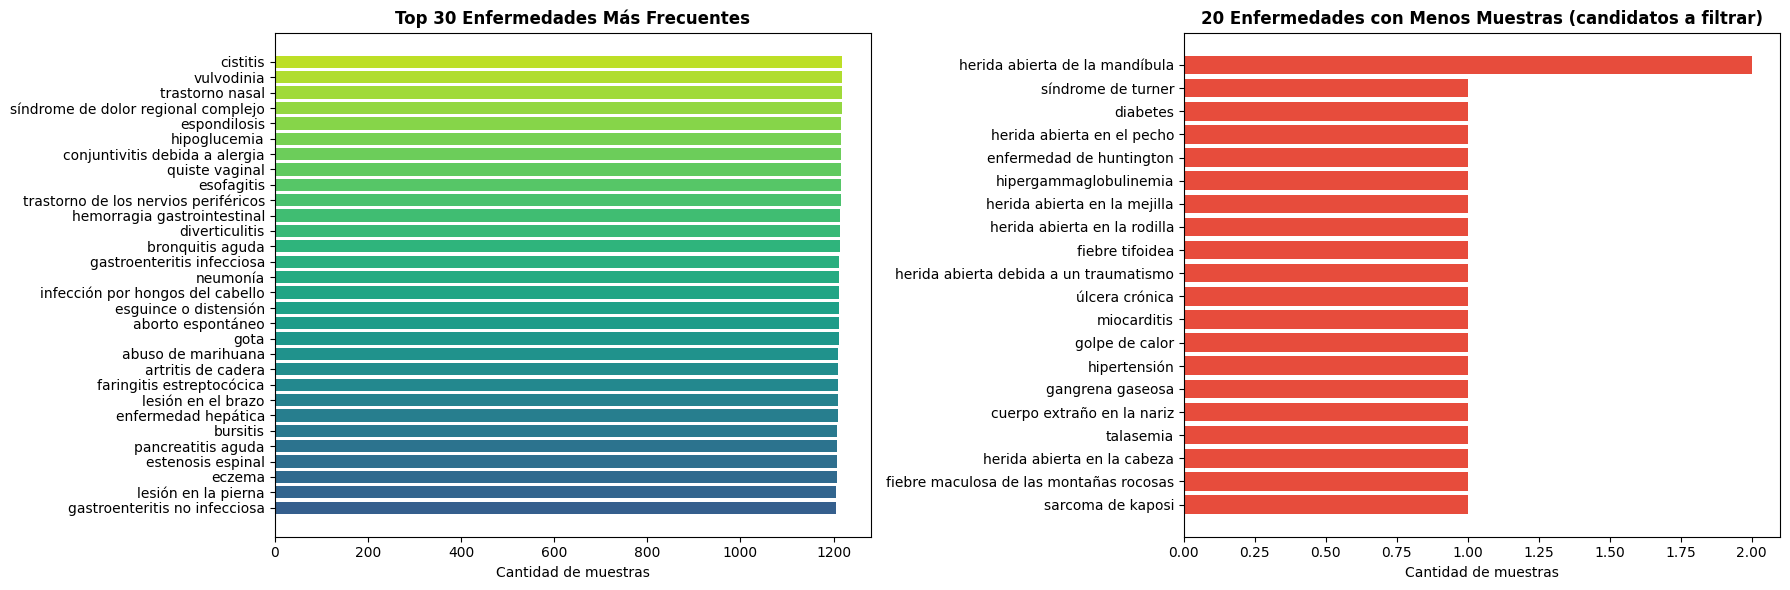


Enfermedades con < 5 muestras: 52
Enfermedades con >= 5 muestras: 721


In [3]:
top_n = 30
conteos = df['enfermedad'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 30
top30 = conteos.head(top_n)
axes[0].barh(top30.index[::-1], top30.values[::-1],
             color=plt.cm.viridis(np.linspace(0.3, 0.9, top_n)))
axes[0].set_xlabel('Cantidad de muestras')
axes[0].set_title(f'Top {top_n} Enfermedades Más Frecuentes', fontweight='bold')

# Bottom 20
bot20 = conteos.tail(20)
axes[1].barh(bot20.index[::-1], bot20.values[::-1], color='#e74c3c')
axes[1].set_xlabel('Cantidad de muestras')
axes[1].set_title('20 Enfermedades con Menos Muestras (candidatos a filtrar)', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'\nEnfermedades con < 5 muestras: {(conteos < 5).sum()}')
print(f'Enfermedades con >= 5 muestras: {(conteos >= 5).sum()}')

## 3. Análisis de síntomas

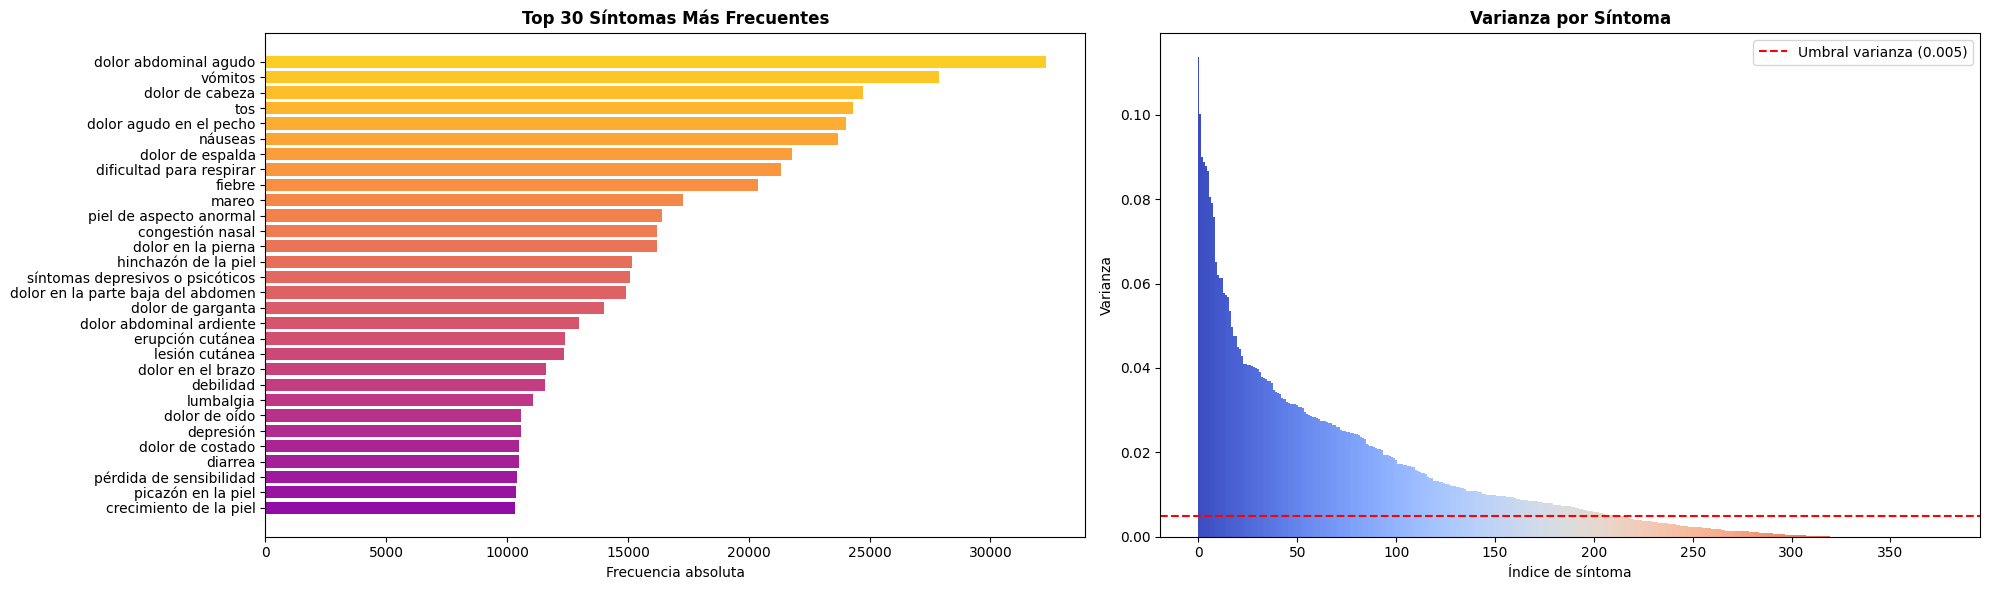

Síntomas con varianza < 0.005: 164
Síntomas útiles (var >= 0.005): 213


In [4]:
# Síntomas más frecuentes (presentes en más pacientes)
freq = df[sintoma_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

top30s = freq.head(30)
axes[0].barh(top30s.index[::-1], top30s.values[::-1],
             color=plt.cm.plasma(np.linspace(0.3, 0.9, 30)))
axes[0].set_xlabel('Frecuencia absoluta')
axes[0].set_title('Top 30 Síntomas Más Frecuentes', fontweight='bold')

# Varianza
varianza = df[sintoma_cols].var().sort_values(ascending=False)
axes[1].bar(range(len(varianza)), varianza.values,
            color=plt.cm.coolwarm(np.linspace(0, 1, len(varianza))), width=1.0)
axes[1].axhline(0.005, color='red', linestyle='--', label='Umbral varianza (0.005)')
axes[1].set_xlabel('Índice de síntoma')
axes[1].set_ylabel('Varianza')
axes[1].set_title('Varianza por Síntoma', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Síntomas con varianza < 0.005: {(varianza < 0.005).sum()}')
print(f'Síntomas útiles (var >= 0.005): {(varianza >= 0.005).sum()}')

## 4. Síntomas promedio por paciente

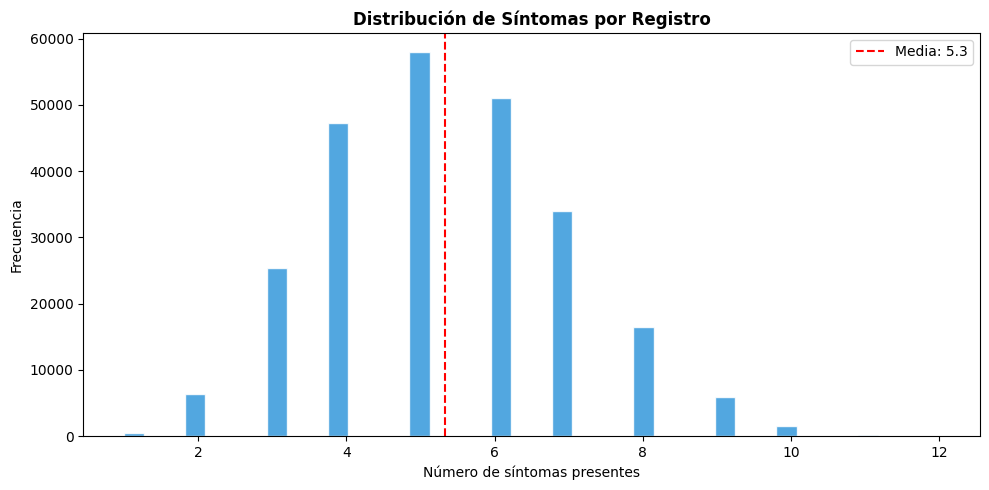

count    246945.000000
mean          5.332851
std           1.640610
min           1.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          12.000000
dtype: float64


In [5]:
sintomas_por_paciente = df[sintoma_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sintomas_por_paciente, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(sintomas_por_paciente.mean(), color='red', linestyle='--',
           label=f'Media: {sintomas_por_paciente.mean():.1f}')
ax.set_xlabel('Número de síntomas presentes')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Síntomas por Registro', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(sintomas_por_paciente.describe())

## 5. Co-ocurrencia de síntomas (heatmap top 20)

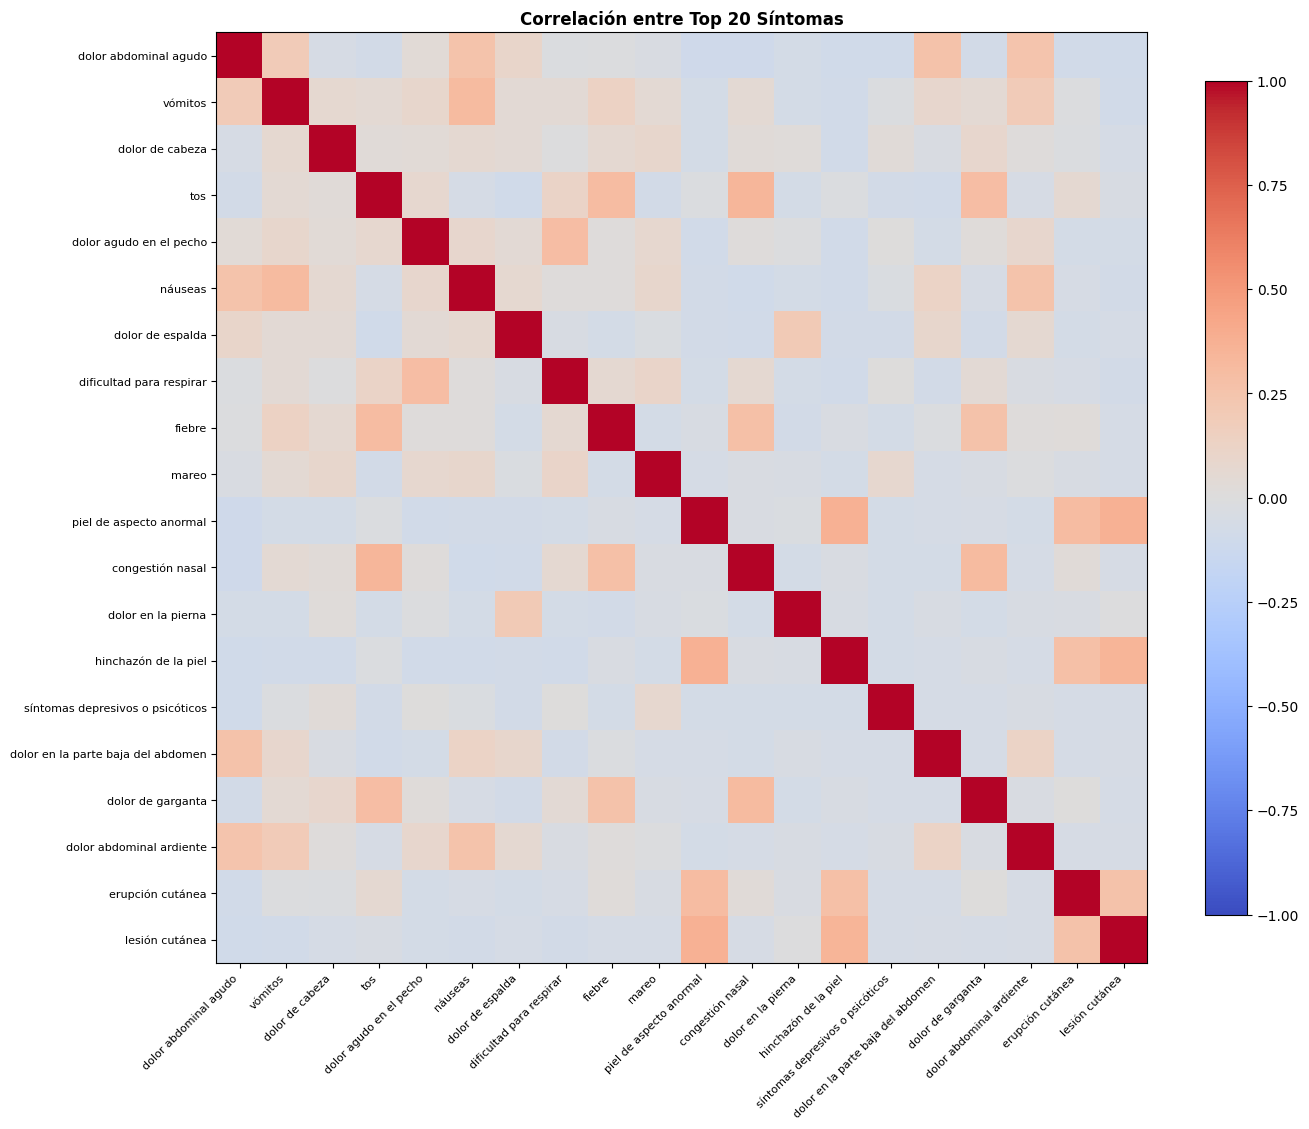

In [6]:
top20_sints = freq.head(20).index.tolist()
corr = df[top20_sints].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_xticks(range(len(top20_sints)))
ax.set_yticks(range(len(top20_sints)))
ax.set_xticklabels(top20_sints, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(top20_sints, fontsize=8)
ax.set_title('Correlación entre Top 20 Síntomas', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Resumen estadístico

In [7]:
print('=== RESUMEN DEL DATASET ===')
print(f'Total registros:          {len(df):,}')
print(f'Total síntomas (bruto):   {len(sintoma_cols)}')
print(f'Síntomas útiles:          {(varianza >= 0.005).sum()}')
print(f'Enfermedades únicas:      {df["enfermedad"].nunique()}')
print(f'Enfermedades >= 5 muestras: {(conteos >= 5).sum()}')
print(f'Promedio síntomas/registro: {sintomas_por_paciente.mean():.1f}')
print(f'Densidad de la matriz:    {df[sintoma_cols].values.mean()*100:.1f}%')

=== RESUMEN DEL DATASET ===
Total registros:          246,945
Total síntomas (bruto):   377
Síntomas útiles:          213
Enfermedades únicas:      773
Enfermedades >= 5 muestras: 721
Promedio síntomas/registro: 5.3
Densidad de la matriz:    1.4%
